In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random


In [2]:
circuito1 = np.zeros(shape=(32, 17))
# Salida
circuito1[-1, 3:9] = 2
# Meta
circuito1[:6, -1] = 3
# Pista
circuito1[:-1, 3:9] = 1
circuito1[:7, 9] = 1
circuito1[:6, 10:-1] = 1
circuito1[1:-3, 2] = 1
circuito1[3:-10, 1] = 1
circuito1[4:14, 0] = 1


In [3]:
circuito2 = np.zeros(shape=(30, 32))
# Salida
circuito2[-1, :-9] = 2
# Meta
circuito2[:9, -1] = 3
# Pista
circuito2[1:-1, 14:16] = 1
circuito2[:-1, 16:23] = 1
for j in range(0, 14):
    circuito2[-3-j:-1, j] = 1
circuito2[1:9, 13] = 1
circuito2[2:8, 12] = 1
circuito2[3:7, 11] = 1
circuito2[:9, -9:-1] = 1
circuito2[9, -9:-2] = 1
circuito2[10, -9:-5] = 1
circuito2[11, -9:-6] = 1
circuito2[12, -9:-8] = 1


In [4]:
class Carrera:
    def __init__(self, circuito):

        self.circuito = np.flipud(circuito).T.astype(int) # Transforma el array para que la celda inferior izquiera sea [0, 0]
        self.circuito_dibujo = circuito
        self.estado = self.salida_aleatoria()
        self.acciones = [(ax, ay) for ax in [-1, 0, 1] for ay in [-1, 0, 1]]

    
    def salida_aleatoria(self):
        celdas_salida = list(zip(*np.where(self.circuito == 2)))
        pos = random.choice(celdas_salida)
        estado = (int(pos[0]), int(pos[1]), 0, 0)
        return estado
    
    
    def visualizar_circuito(self):
        TAM_CELDA = 20
        COLORES = {
            0: (0, 0, 0),       # Muro -> Negro
            1: (255, 255, 255), # Pista -> Blanco
            2: (255, 0, 0),     # Salida -> Rojo
            3: (0, 255, 0),     # Meta -> Verde
        }

        h, w = self.circuito_dibujo.shape
        img = np.zeros((h * TAM_CELDA, w * TAM_CELDA, 3), dtype=np.uint8)

        # Dibuja las celdas del circuito
        for i in range(h):
            for j in range(w):
                color = COLORES[self.circuito_dibujo[i, j]]
                y1, y2 = i * TAM_CELDA, (i + 1) * TAM_CELDA
                x1, x2 = j * TAM_CELDA, (j + 1) * TAM_CELDA
                img[y1:y2, x1:x2] = color

        # Dibuja una rejilla para diferenciar las celdas
        for i in range(h + 1):
            y = i * TAM_CELDA
            cv2.line(img, (0, y), (w * TAM_CELDA, y), (200, 200, 200), 1)

        for j in range(w + 1):
            x = j * TAM_CELDA
            cv2.line(img, (x, 0), (x, h * TAM_CELDA), (200, 200, 200), 1)

        return img


Circuito 1:


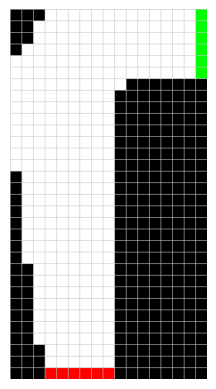


Circuito 2:


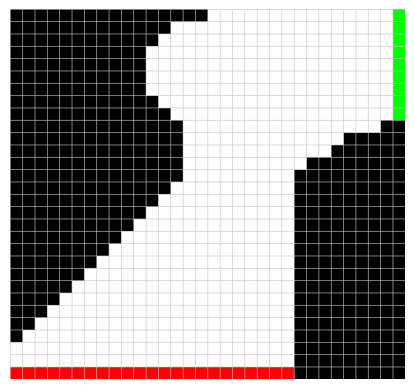

In [5]:
coche1 = Carrera(circuito1)
img_circuito1 = coche1.visualizar_circuito()
print('Circuito 1:')
plt.axis('off')
plt.imshow(img_circuito1)
plt.show()

coche2 = Carrera(circuito2)
img_circuito2 = coche2.visualizar_circuito()
print('\nCircuito 2:')
plt.axis('off')
plt.imshow(img_circuito2)
plt.show()